In [1]:
import tensorflow as tf
print("Versi TensorFlow:", tf.__version__)
print("Jumlah GPU yang Tersedia:", len(tf.config.experimental.list_physical_devices('GPU')))

2024-07-05 01:27:54.082667: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-05 01:27:54.082775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-05 01:27:54.234449: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versi TensorFlow: 2.15.0
Jumlah GPU yang Tersedia: 1


In [2]:
import tensorflow as tf
print("GPU Tersedia:", tf.test.is_gpu_available())

GPU Tersedia: True


In [3]:
import pandas as pd

# Membaca file CSV
data = pd.read_csv('/kaggle/input/fix-round3-plain-cipher-label-all-new-shuffled/FIX-round3-plain-cipher-label-all-new-shuffled.csv', dtype={'plaintext': str, 'ciphertext': str})

# Menampilkan jumlah data dengan label 0 dan 1
label_counts = data['label'].value_counts()
print("Jumlah data dengan label 0:", label_counts[0])
print("Jumlah data dengan label 1:", label_counts[1])

Jumlah data dengan label 0: 524291
Jumlah data dengan label 1: 524288


In [4]:
data['label'].unique()

array([0, 1])

In [5]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext     object
ciphertext    object
label          int64
dtype: object


In [6]:
data.tail(3)

,plaintext,ciphertext,label
1048576,01001111010011010100011100100000,01110101101111100101100100011110,1
1048577,01101000011101000111010001110000,01110010011101011101010000101110,0
1048578,00100000011100110111010001110101,01101111000101010010111010001100,1


In [7]:
from sklearn.preprocessing import OneHotEncoder

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split

# Mengkonversi data result menjadi representasi numerik (one-hot encoding)
data['concated_features'] = data['plaintext'] + data['ciphertext'].astype(str)

X = []
for binary_string in data['concated_features']:
    one_hot_encoding = [int(bit) for bit in binary_string]
    X.append(one_hot_encoding)

X = np.array(X, dtype=np.int64)
Y = data['label']

In [8]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext            object
ciphertext           object
label                 int64
concated_features    object
dtype: object


In [9]:
data.head(3)

,plaintext,ciphertext,label,concated_features
0,00100000011010100110010101101110,11111100110000000110001000011010,0,0010000001101010011001010110111011111100110000...
1,00100000011011010110100101100011,00001100110100101100011100011000,1,0010000001101101011010010110001100001100110100...
2,00100000011100110110000101101000,11011000100101010111000101000011,0,0010000001110011011000010110100011011000100101...


In [10]:
print(X)

[[0 0 1 ... 0 1 0]
 [0 0 1 ... 0 0 0]
 [0 0 1 ... 0 1 1]
 ...
 [0 1 0 ... 1 1 0]
 [0 1 1 ... 1 1 0]
 [0 0 1 ... 1 0 0]]


In [11]:
print(Y)

0          0
1          1
2          0
3          0
4          0
          ..
1048574    1
1048575    1
1048576    1
1048577    0
1048578    1
Name: label, Length: 1048579, dtype: int64


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from keras.layers import Input, Conv1D, BatchNormalization, Add, Flatten, Dense, AveragePooling1D, Concatenate, Reshape
from keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Add, Dense, Flatten, Dropout, LSTM, AdditiveAttention, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [13]:
input_shape = (64, )  # Input shape for concated_features

In [14]:
# Definisikan fungsi attention
def bahdanau_attention(input_first_half, input_second_half):
    # Perhitungan skor perhatian menggunakan BahdanauAttention
    attention = layers.AdditiveAttention()([input_first_half, input_second_half])
    # Kembalikan hasil perhatian
    return attention

In [15]:
def create_cnn_model(input_shape):
    # Input layer
    input_layer = layers.Input(shape=input_shape)

    # Reshape input to (batch_size, timesteps, input_dim)
    reshape_layer = layers.Reshape((64, 1))(input_layer)

    # Convolutional layers
    conv_layer_1 = layers.Conv1D(filters=32, kernel_size=9, activation='relu', padding='same')(reshape_layer)
    batch_norm_layer_1 = layers.BatchNormalization()(conv_layer_1)

    # Average Pooling layer
    average_pooling_layer = layers.AveragePooling1D(pool_size=2)(batch_norm_layer_1)

    for _ in range(3):
        # Conv1D layer
        conv_layer = layers.Conv1D(filters=32, kernel_size=9, activation='relu', padding='same')(average_pooling_layer)
        batch_norm_layer = layers.BatchNormalization()(conv_layer)

        # Skip connection
        skip = layers.Add()([batch_norm_layer, average_pooling_layer])

        # Update average_pooling_layer for the next iteration
        average_pooling_layer = skip

    # LSTM layer with return_sequences=True
    lstm_layer = layers.LSTM(32, return_sequences=True)(average_pooling_layer)
    lstm_output = layers.TimeDistributed(layers.Dense(32))(lstm_layer)

    # Bagi input menjadi dua bagian terpisah menggunakan lapisan Lambda
    split_input = layers.Lambda(lambda x: tf.split(x, num_or_size_splits=2, axis=-1))(lstm_output)
    input_first_half, input_second_half = split_input

    # Terapkan mekanisme perhatian
    attention_output = bahdanau_attention(input_first_half, input_second_half)

    # Flatten output dari LSTM
    flatten_output = layers.Flatten()(attention_output)

    # Dense layers
    dense_layer_1 = layers.Dense(32, activation='relu')(flatten_output)
    dense_layer_2 = layers.Dense(32, activation='relu')(dense_layer_1)
    dense_layer_3 = layers.Dense(32, activation='relu')(dense_layer_2)
    dense_layer_4 = layers.Dense(32, activation='relu')(dense_layer_3)
    dense_layer_5 = layers.Dense(32, activation='relu')(dense_layer_4)
    dense_layer_6 = layers.Dense(32, activation='relu')(dense_layer_5)
    dense_layer_7 = layers.Dense(32, activation='relu')(dense_layer_6)
    dense_layer_8 = layers.Dense(32, activation='relu')(dense_layer_7)
    dense_layer_9 = layers.Dense(32, activation='relu')(dense_layer_8)
    dense_layer_10 = layers.Dense(32, activation='relu')(dense_layer_9)
    dense_layer_11 = layers.Dense(32, activation='relu')(dense_layer_10)
    dense_layer_12 = layers.Dense(32, activation='relu')(dense_layer_11)
    dense_layer_13 = layers.Dense(32, activation='relu')(dense_layer_12)
    dense_layer_14 = layers.Dense(32, activation='relu')(dense_layer_13)
    dense_layer_15 = layers.Dense(32, activation='relu')(dense_layer_14)
    dense_layer_16 = layers.Dense(32, activation='relu')(dense_layer_15)
    dense_layer_17 = layers.Dense(32, activation='relu')(dense_layer_16)

    output_layer = layers.Dense(1, activation='sigmoid')(dense_layer_17)

    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [16]:
# Gunaka early-stopping untuk menentukan optimal epoch
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)
    #tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)
]

In [17]:
# Create the CNN model
cnn_model = create_cnn_model(input_shape)
# Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 1)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 32)    │        320 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 32, 32)    │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 32)    │      9,248 │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 32)    │      9,248 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 32)    │      9,248 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32, 32)    │      8,320 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 32, 32)    │      1,056 │ lstm[0][0]        │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ [(None, 32, 16),  │          0 │ time_distributed… │
│                     │ (None, 32, 16)]   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ (None, 32, 16)    │         16 │ lambda[0][0],     │
│ (AdditiveAttention) │                   │            │ lambda[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ additive_attenti

 Total params: 71,313 (278.57 KB)

 Trainable params: 71,057 (277.57 KB)

 Non-trainable params: 256 (1.00 KB)

In [18]:
# Training, validasi, dan tes

In [19]:
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training (60%), validasi (20%), dan test (20%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Output informasi ukuran dataset
print("Ukuran dataset pelatihan (X_train):", X_train.shape)
print("Ukuran dataset validasi (X_val):", X_val.shape)
print("Ukuran dataset pengujian (X_test):", X_test.shape)

Ukuran dataset pelatihan (X_train): (838863, 64)
Ukuran dataset validasi (X_val): (104858, 64)
Ukuran dataset pengujian (X_test): (104858, 64)


In [20]:
cnn_history = cnn_model.fit(X_train, Y_train, epochs=100, batch_size=100, callbacks=my_callbacks, validation_data=(X_val, Y_val))

Epoch 1/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 154s 17ms/step - accuracy: 0.5748 - loss: 0.6379 - val_accuracy: 0.7918 - val_loss: 0.3765
Epoch 2/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 141s 17ms/step - accuracy: 0.8270 - loss: 0.3321 - val_accuracy: 0.8630 - val_loss: 0.2705
Epoch 3/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 141s 17ms/step - accuracy: 0.8721 - loss: 0.2477 - val_accuracy: 0.8824 - val_loss: 0.2312
Epoch 4/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 142s 17ms/step - accuracy: 0.8879 - loss: 0.2168 - val_accuracy: 0.8878 - val_loss: 0.2222
Epoch 5/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 142s 17ms/step - accuracy: 0.8973 - loss: 0.1988 - val_accuracy: 0.8976 - val_loss: 0.1977
Epoch 6/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 145s 17ms/step - accuracy: 0.9038 - loss: 0.1860 - val_accuracy: 0.9032 - val_loss: 0.1916
Epoch 7/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 148s 18ms/step - accuracy: 0.9072 - loss: 0.1787 - val_accuracy: 0.9059 - val_loss: 0.1907
Epoch 8/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 148s 18ms/step - ac

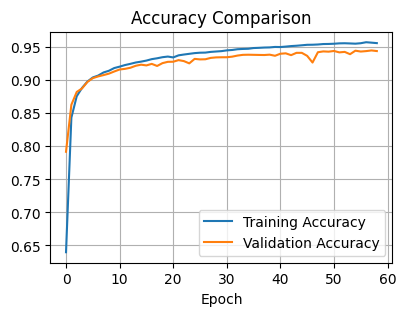

In [21]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.grid()

In [22]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test, Y_test)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9448 - loss: 0.1275


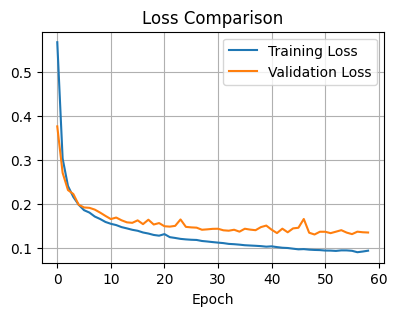

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.grid()
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns

# Predict labels for test set
Y_pred = cnn_model.predict(X_test)
Y_pred_classes = np.round(Y_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(Y_test, Y_pred_classes)
precision = precision_score(Y_test, Y_pred_classes)
recall = recall_score(Y_test, Y_pred_classes)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


In [25]:
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[49740  2876]
 [ 3053 49189]]
Accuracy: 0.9434568654752141
Precision: 0.944761355997311
Recall: 0.9415604303051185


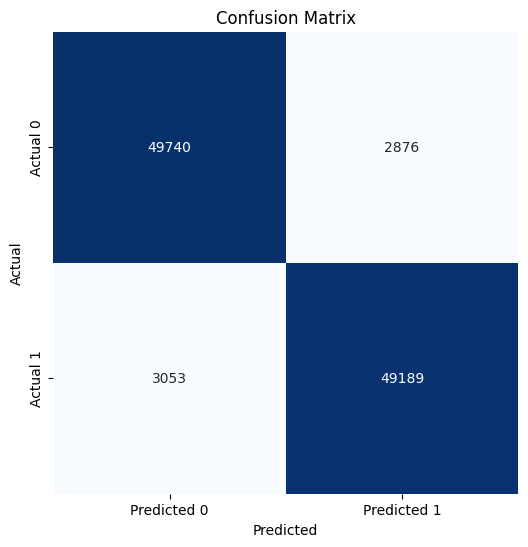

In [26]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.title('Confusion Matrix')
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

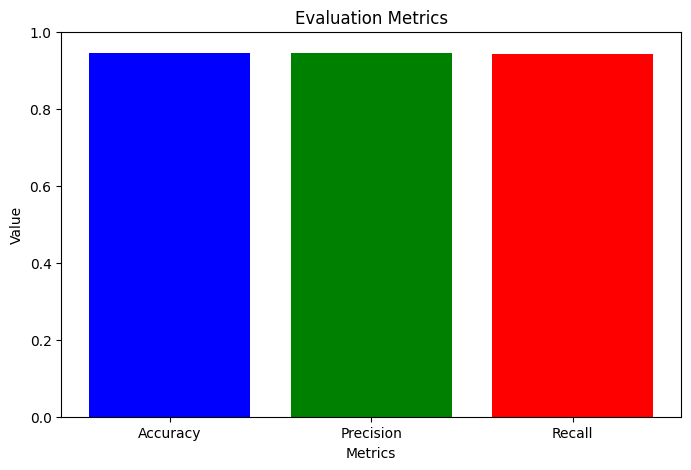

In [27]:
# Plot evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall']
values = [accuracy, precision, recall]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Value')
plt.ylim(0, 1)
plt.show()